<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#0400ffff'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
- [5. Data Cleaning](#5)
    - [5.1. Numeric Features Correction](#5_1)
    - [5.2. Categorical Features Correction](#5_2)
        - [5.2.1. Correct the values](#5_2_1)
        - [5.2.2. Check corrections](#5_2_2)
- [6. Data Partition](#6)
- [7. Feature Engineering & Preprocessing](#7)
    - [7.1. Outliers Treatment](#7_1)
    - [7.2. Feature Engineering ](#7_2)
    - [7.3. Encoding](#7_3)
    - [7.4. Scaling Features](#7_4)
    - [7.3. Missing Values Imputation](#7_3)
- [8. Feature Selection](#8)
    - [8.1. Remove paintQuality%](#8_1)
    - [8.2. Filter Methods](#8_2)
        - [8.2.1. Removing Constant Features](#8_2_1)
        - [8.2.2. Correlation between features - Redundant Features](#8_2_2)
        - [8.2.3. Correlation with the target - Relevant Features](#8_2_3)
    - [8.3. Wrapped Methods](#8_3)
        - [8.3.1. RFE](#8_3_1)
    - [8.4. Embedded Methods](#8_4)
        - [8.4.1. Lasso](#8_4_1)
    - [8.5. Feature Importance](#8_5)
    - [8. Comparison between Models](#8_6)
- [9. Model and Evaluation](#9)
    - [9.1. Create a Sample to Test Models](#9_1)
    - [9.2. Define the Scores to Evaluate](#9_2)
    - [9.3. Test Different Models](#9_3)
        - [9.3.1. Linear Regression](#9_3_1)
        - [9.3.2. Ridge](#9_3_2)
        - [9.3.3. Lasso](#9_3_3)
        - [9.3.4. Elastic Net](#9_3_4)
        - [9.3.5. K-Nearest Neighbors (KNN)](#9_3_5)
        - [9.3.6. Neural Networks](#9_3_6)
        - [9.3.7. Decision Trees](#9_3_7)
        - [9.3.8. Ensemble Methods](#9_3_8)
            - [9.3.8.1. With Decision Trees](#9_3_8_1)
            - [9.3.8.2. Random Forest](#9_3_8_2)
            - [9.3.8.3. Extra Trees](#9_3_8_3)
            - [9.3.8.4. With Neural Networks](#9_3_8_4)
- [10. Models Resuls Comparison & Save to Kaggle](#10)
- [11. Open-Ended](#11)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOP](#TOP)
</a>

!!!colocar o abstract final depois 

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOP](#TOP)
</a>

To embark on this project, it is essential to import the necessary libraries which play a pivotal role in efficient data management and predictive model development. 

This approach employed the use of NumPy and Pandas for the manipulation of data, and Plotly for the creation of interactive visualisations. Statistical tests were conducted using SciPy, while the preprocessing and modelling were dependent on scikit-learn, including tools for imputation, scaling, and a variety of machine learning algorithms. Performance evaluation was carried out using MAE and $R^2$ metrics.

In [22]:
# General Useful Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math

# Text Similarity - Categorical Features Correction
from difflib import SequenceMatcher

# Scaling and Encoding
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder, MinMaxScaler, StandardScaler, RobustScaler

# Missing Value Imputation
from sklearn.impute import KNNImputer, SimpleImputer

# Data Partition
from sklearn.model_selection import train_test_split

#filter methods
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr

# spearman 
from sklearn.feature_selection import SelectKBest, f_regression

# mutual information
from sklearn.feature_selection import mutual_info_classif

#wrapper methods
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

# embedded methods
from sklearn.linear_model import Lasso

from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

# Linear Models
from sklearn.linear_model import Ridge, Lasso, ElasticNet

#KNN
from sklearn.neighbors import KNeighborsRegressor

# Random Forest
from sklearn.ensemble import RandomForestRegressor

#Neural Network
from sklearn.neural_network import MLPRegressor

# DecisionTree
from sklearn.tree import DecisionTreeRegressor

# Ensemble
from sklearn.ensemble import BaggingRegressor, ExtraTreesRegressor, RandomForestRegressor

#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
import sys
sys.path.append("../")

from Source.visualizations import *
from Source.data_preprocessing import *
from Source.feature_engineering import *
from Source.feature_selection import *
from Source.model_and_assessment import *

# Set random seed for reproducibility
np.random.seed(40111)

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#TOP)
</a>

Understanding the features is essential to interpret the data correctly and conduct the subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An attribute that contains an identifier for each car.

**Brand:** The car's main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** The type of fuel used by the car (Diesel, Petrol, Hybrid, Electric).

**mpg:** The car's consumption of fuel expressed in average miles per gallon.

**engineSize:** Size of the engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOP](#TOP)
</a>

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets for each individual car.

In [23]:
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Data Cleaning**

[Back to TOP](#TOP)
</a>

In this section, the objective is to clean the dataset by correcting inconsistencies identified during the exploratory data analysis (EDA) phase, across both numerical and categorical features. This process is supported by a dedicated .py file, which contains a set of helper functions developed to streamline and standardize the data cleaning workflow.

Data cleaning is a critical step toward the project’s final objective of accurately predicting the target variable. Errors and inconsistencies in the data can directly affect how the model learns underlying patterns, ultimately impacting its ability to generalize and produce reliable predictions. 

<a class="anchor" id="5_1">

## **5.1** Numeric Features Correction
[Back to TOP](#TOP)
</a>

The inconsistencies that were identified in the numerical features and that are addressed in this subsection are:

- The columns `Year`, `hasDamage` and `previousOwners` contain floating point values, although they represent discrete variables (and a boolean variable in the case of hasDamage) and should therefore only contain integer values.

- Some features contain negative values that are not meaningful in the context of the data.

- The hasDamage feature is binary but contains only values of 0 and NaN, suggesting that missing values may implicitly represent the presence of damage (1).

To correct these issues, the following actions are applied:

- The integer component of floating point values is the only component retained for features that should be represented as integers.

- Negative values are replaced with NaN and subsequently treated as missing values in later preprocessing steps.

- Missing values in the hasDamage feature is replaced with 1, under the assumption that they indicate the presence of damage.

- With respect to the negative values observed in the tax feature, an alternative hypothesis was considered: these values might represent tax incentives for electric vehicles. This assumption will be evaluated by analysing the relationship between negative tax values and vehicle fuel type.

In [24]:
negtax_electric = train[(train['tax'] < 0) & (train['fuelType'] == 'Electric')]
print(f"Number of rows with negative 'tax' and 'Electric' fuel type: {len(negtax_electric)}")
negtax_electric[['tax', 'fuelType']].head(10)

Number of rows with negative 'tax' and 'Electric' fuel type: 0


,tax,fuelType
carID,,


From this analysis, it was concluded that no electric vehicles are associated with negative tax values. Therefore, this hypothesis was discarded, and all negative values were corrected using a custom function implemented in the data_preprocessing.py file.

In [25]:
train = correct_metric_features(train)
test = correct_metric_features(test)

<a class="anchor" id="5_2">

## **5.2** Categorical Features Correction

[Back to TOP](#TOP)

As identified in the EDA phase, several categorical features contain a significant number of misspellings and inconsistent labels. These issues are addressed in this subsection using a custom function specifically developed to standardize categorical values.

The correction process relies on string similarity techniques to identify and group semantically equivalent values. Thresholds for similarity were determined through a trial and error approach, as the optimal values vary depending on both the length of the words and the number of unique observations within each feature.

To account for these differences, two similarity thresholds were defined: one for shorter strings (≤ 5 characters) and another for longer strings (> 5 characters). This distinction is particularly important because the similarity metric used (SequenceMatcher) is ratio based, meaning that each character contributes differently to the overall similarity score depending on word length.

This approach proved especially relevant for the model feature, which contains a large number of unique and highly similar values. Given its high cardinality and sensitivity to minor spelling variations, the use of differentiated thresholds was essential to ensure accurate and consistent categorical correction.

<a class="anchor" id="5_2_1">

### **5.2.1** Correct the values

[Back to TOP](#TOP)

In [26]:
# Correct 'Brand' column
train = clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
test = clean_with_diff(test, 'Brand', threshold_short=0.6, threshold_long=0.6)

# Correct 'transmission' column
train = clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
test = clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
train = clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
test = clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
train = clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
test = clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

<a class="anchor" id="5_2_2">

### **5.2.2** Check corrections

[Back to TOP](#TOP)

In [27]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' Kona'
 ' Mokka' ' S-MAX' ' Crossland X' ' Tiguan' ' A5' ' Zafira' ' Ioniq' ' A6'
 ' Mondeo' ' Yeti Outdoor' ' X1' ' Scala' ' SL CLASS' ' 1 Series' ' Kamiq'
 ' Kuga' ' Tourneo Connect' ' Q7' ' Arteon' ' Santa Fe' ' Grandland X'
 ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly. However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained a high number of unique and incorrect values, some of which were very similar to each other, having just one character difference between the wrong and correct model, but also just one different character from another model's name. This makes it impossible to achieve a perfect correction with this approach.

Example: 2 Serie (wrong), 3 Serie (wrong), 2 Series (correct), 3 Series (correct)

Nevertheless, the vast majority of the data is now properly cleaned and corrected and we will stick with this method.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [28]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is very small so we are going to replace the category as mentioned before.

In [29]:
train = replace_category_transmission(train)
test = replace_category_transmission(test)

<a class="anchor" id="6">

# **6. Data Partition**

[Back to TOP](#TOP)

In this section, the dataset is partitioned into independent and dependent variables, where the independent features are defined as X and the target variable (price) as y. This separation is essential to clearly distinguish the inputs used by the model from the value it is expected to predict.

Subsequently, the data is split into training and validation sets using the holdout method. This step allows the models to be trained on a subset of the data while being evaluated on unseen observations, providing a more realistic assessment of their generalization capability. This is also a critical measure to prevent data leakage, which occurs when information from the validation set influences the training process. 

After the split, all preprocessing steps that rely on statistical properties of the data (such as outlier detection, imputation, or scaling) are computed exclusively using the training set and then applied to the validation set.

This approach ensures that model evaluation remains unbiased and that the reported performance metrics accurately reflect how the model would behave when exposed to new, unseen data.

In [30]:
X = train.drop('price', axis = 1)
y = train['price']

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, random_state = 42,  shuffle = True)

<a class="anchor" id="7">

# **7. Feature Engineering & Preprocessing**

[Back to TOP](#TOP)

In this section, the datasets previously defined using the holdout method are used to perform feature engineering and preprocessing. The workflow begins with outlier treatment, followed by feature engineering, where new variables are created with the objective of enhancing the model’s ability to capture relevant patterns in the data and, consequently, improving its predictive performance.

After feature creation, categorical features are encoded into a numerical format suitable for machine learning algorithms. This step is followed by feature scaling, which is applied to ensure that all variables are on a comparable scale and to support algorithms that are sensitive to feature magnitude.

The final preprocessing step consists of handling missing values. In this project, missing value imputation is performed using a K-Nearest Neighbors (KNN) approach, which requires scaled data in order to compute meaningful distances between observations. For this reason, imputation is applied after the scaling step.

All preprocessing transformations are learned exclusively from the training dataset and then applied to the validation dataset using the same parameters. This strategy prevents data leakage and ensures that the model evaluation reflects a realistic scenario in which the model is exposed to new, unseen data. Properly designed feature engineering and preprocessing steps play a critical role in improving model robustness, generalization ability, and overall performance.

<a class="anchor" id="7_1">

## **7.1** Outliers Treatment

[Back to TOP](#TOP)

To identify outliers, the Interquartile Range (IQR) method was initially selected and applied to all numerical features. This method is robust to skewed distributions and does not rely on distributional assumptions, making it suitable for exploratory outlier detection in heterogeneous datasets.

The initial analysis focuses on quantifying the number and percentage of outliers per feature, providing an overview of their relative impact on the dataset. This summary is computed exclusively on the training dataset, in line with best practices to prevent data leakage.
A custom function was implemented to return a summary table containing the total number of detected outliers per feature and their corresponding percentage relative to the total number of observations.

To identify outliers, we decided to use the **Interquartile Range (IQR) method** and apply it to all numerical features.

The following analysis identifies the number and percentage of outliers per features, helping to evaluate whether data cleaning or transformation is be necessary before modeling.

In [31]:
outlier_summary(X_train)

,Column,Total Outliers,Percentage (%)
0,year,1423,2.34
1,mileage,2570,4.23
2,tax,15939,26.22
3,mpg,947,1.56
4,engineSize,508,0.84
5,paintQuality%,0,0.00
6,previousOwners,0,0.00
7,hasDamage,1237,2.04


Based on the IQR-based summary, most numerical features exhibit a relatively small proportion of outliers, typically representing less than 5% of the observations. The notable exception is the tax feature, for which outliers account for 26.22% of the dataset.
Given this discrepancy, a graphical inspection using boxplots was conducted to better understand the distribution and magnitude of outliers across features.

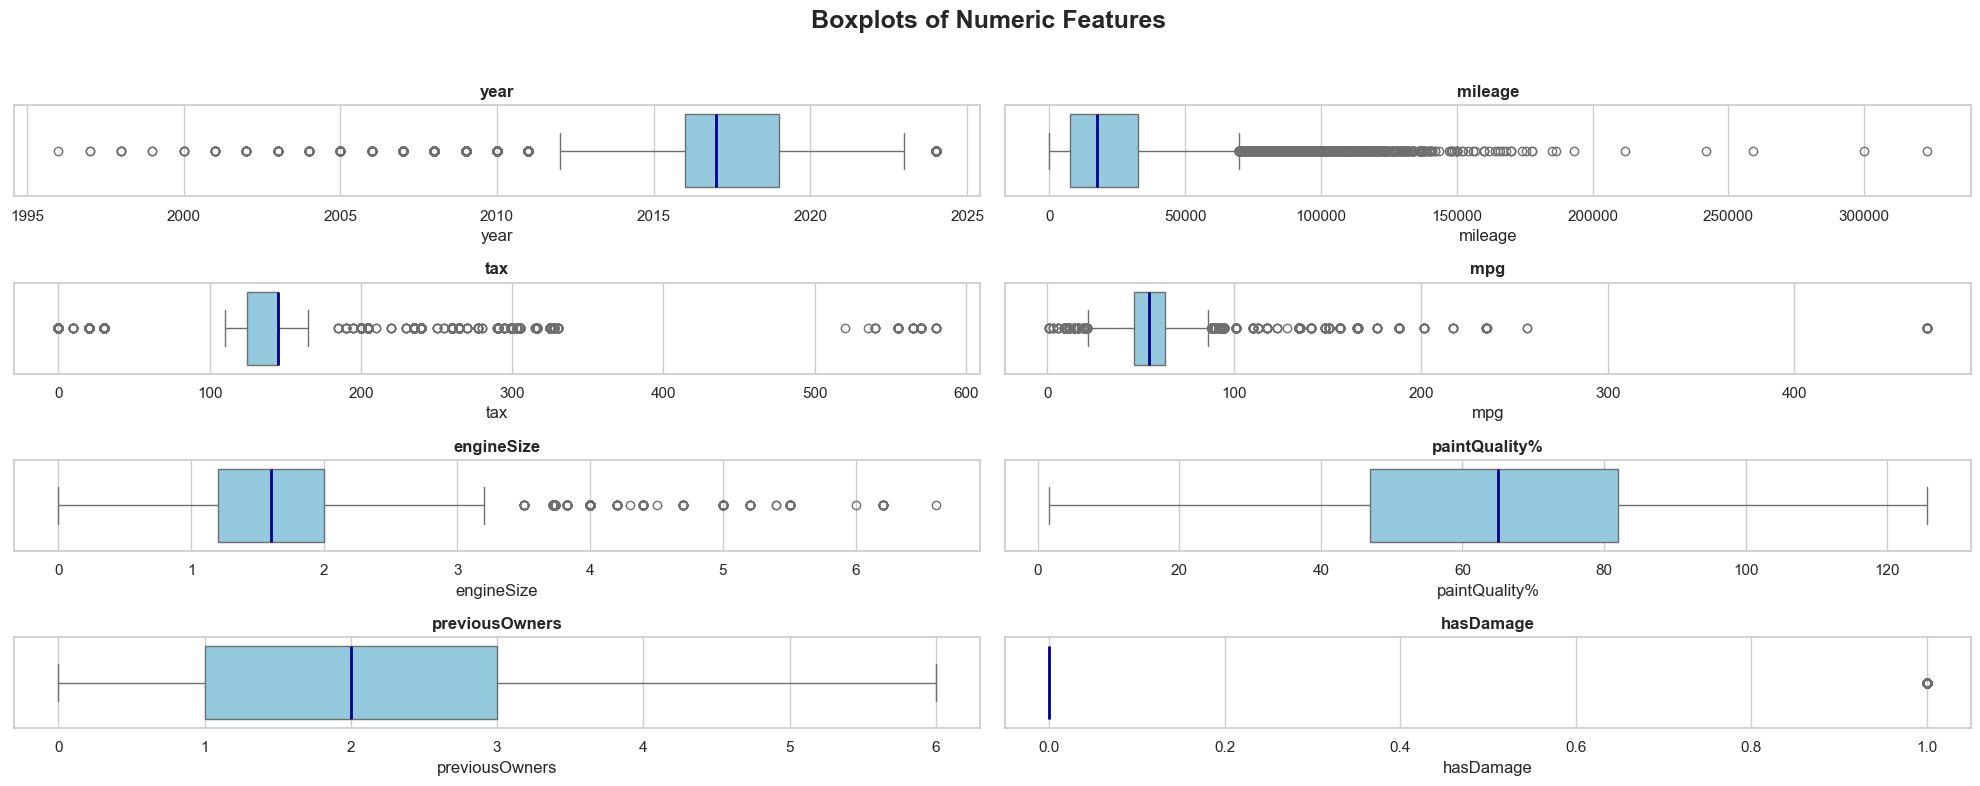

In [32]:
create_boxplots(X_train)

After applying the standard IQR method (1.5 × IQR), it became evident that this approach was overly restrictive for certain features, resulting in the removal of a substantial number of observations. We believe that this reduction in data volume will negatively affect model performance.

To address this issue, feature specific thresholds were defined, combining domain knowledge with empirical evaluation. These thresholds aim to strike a balance between removing extreme and unrealistic values while preserving legitimate variability in the data.

The final thresholds applied are:

- `year:` values restricted to the range 1990–2020
- `mileage`,`tax`, `mpg:` 2.2 × IQR multiplier
- `engineSize:` values restricted to 0.9L–5.5L
- `previousOwners:` values restricted to 0–6

The choice of a 2.2 IQR multiplier and the definition of fixed bounds for certain features were determined through a trial and error process. This value was selected as an effective compromise, widening the acceptance range compared to the default IQR threshold while still removing extreme outliers that adversely impact model accuracy.

The rationale for each feature-specific threshold is outlined below:

- `year:` Vehicles manufactured before 1990 are extremely rare in the dataset and introduce substantial price variability, while values beyond 2020 are not feasible given the dataset’s temporal scope. Restricting this range improves data realism and model stability.

- `mileage:` This feature exhibits strong right skewness. Applying a 2.2 IQR multiplier limits extreme mileage values that disproportionately reduce model accuracy while preserving legitimate high mileage vehicles.

- `tax:` Extremely high tax values occur infrequently and are often associated with errors or exceptional cases. The adjusted IQR threshold mitigates the influence of these unrealistic values.

- `mpg:` Extreme fuel efficiency values are uncommon and distort price relationships. A widened IQR threshold constrains these extremes while maintaining meaningful variability across vehicle models.

- `engineSize:` Values below 0.9L or above 5.5L correspond either to niche cases or data errors. Bounding this feature ensures realistic engine size ranges and reduces skewness.

- `previousOwners:` The IQR visualization indicates no statistical outliers for this feature; however, values above 6 previous owners are highly atypical and likely reflect noisy observations. Capping this feature limits their undue influence on price prediction.

Based on the refined thresholds and feature specific analysis, the custom outlier treatment is applied to the training dataset, and the same thresholds are subsequently used for the validation and test dataset to ensure consistency and prevent data leakage.


In [33]:
X_train_clean = treat_outliers_custom(X_train, X_train)
X_val_clean = treat_outliers_custom(X_train, X_val)
test_clean = treat_outliers_custom(X_train, test)

# Update original datasets with cleaned versions
X_train = X_train_clean.copy()
X_val = X_val_clean.copy()
test = test_clean.copy()

<a class="anchor" id="7_2">

## **7.2** Feature Engineering

[Back to TOP](#TOP)

At this stage of the project, new features were created with the objective of enhancing the model’s predictive power by incorporating domain knowledge and more informative representations of the original variables. The engineered features fall into two main categories:

1. Features derived directly from existing variables, without relying on statistical aggregates such as the mean, median, or mode.

2. Features computed using statistical aggregation, which are calculated exclusively on the training dataset (X_train) to prevent data leakage.

The following sections describe each engineered feature and the rationale behind its inclusion.

**1. Directly Engineered Features**

- `car_age:` Calculates the age of the vehicle based on the year of registration and the reference year. This feature captures depreciation effects, as older vehicles generally exhibit lower market prices.

- `is_recent_car:` Binary indicator equal to 1 if the car is less than three years old, and 0 otherwise. This feature highlights newer vehicles, which typically retain higher resale values.

- `mileage_category:` Converts the continuous mileage feature into an ordered categorical variable with five usage levels. This transformation facilitates the capture of differences in vehicle wear and market value associated with mileage intensity.

- `is_hybrid_or_eletric:` Binary indicator equal to 1 if the vehicle’s fuel type is Hybrid or Electric. Environmentally friendly vehicles often command higher prices due to lower running costs and regulatory incentives.

- `is_automatic:` Binary indicator equal to 1 if the transmission type is automatic or semi-automatic. Automatic vehicles generally have higher purchase and maintenance costs, which is reflected in their resale prices.

- `fuel_eficciency_score:` Ratio of mpg to engineSize, capturing how efficiently the vehicle converts fuel relative to engine capacity.

- `tax_to_engine_ratio:` Ratio of vehicle tax to engine size, providing an estimate of maintenance cost relative to engine power.

- `tax_efficency:` Ratio of mpg to tax, measuring fuel efficiency in relation to annual taxation burden.

- `is_first_owner:` Binary indicator equal to 1 if the vehicle has had no previous owners. First owner cars are typically associated with lower wear, better maintenance, and higher market value.

**2. Features Based on Statistical Aggregation (Train-Only)**

- `brand_median_mileage:` Median mileage per brand, capturing typical usage patterns associated with each manufacturer.

- `brand_avg_engineSize`: Mean engine size per brand, representing the typical engine capacity offered by each manufacturer.

- `model_median_tax:` Median tax value per model, capturing model-specific taxation characteristics.

- `fueltype_avg_mpg:` Mean fuel efficiency (mpg) per fuel type, representing typical consumption levels across fuel categories.

- `brand_avg_age:` Mean vehicle age per brand, allowing differentiation between brands that typically offer newer versus older vehicles in the dataset.

All feature engineering steps were encapsulated in a dedicated function implemented in the feature_engineering.py file. This function was previously imported and is applied consistently to the datasets as part of the preprocessing workflow.


In [34]:
X_train.shape

(60778, 12)

In [35]:
X_train_fe = create_features(X_train, X_train, current_year=2020, threshold=3)
X_val_fe = create_features(X_train, X_val, current_year=2020, threshold=3)
test_fe = create_features(X_train, test, current_year=2020, threshold=3)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

In [36]:
X_train.shape

(60778, 26)

<a class="anchor" id="7_3">

## **7.3** Encoding

[Back to TOP](#TOP)

Before training machine learning models, categorical features must be transformed into numerical representations, as most algorithms are unable to process non-numeric data directly. This step, known as encoding, ensures that categorical information is incorporated into the model in a meaningful and efficient way.

In this project, a combination of Target Encoding, One-Hot Encoding and Ordinal Encoding is used, with the choice of method depending on the nature and cardinality of each categorical feature. All encoders are fitted exclusively on the training dataset and then applied to the validation (and test) datasets to prevent data leakage.

`Target Encoding` is applied to high cardinality categorical features (Brand and model). This approach replaces each category with a numerical value derived from the target variable, allowing the model to capture category specific price tendencies without substantially increasing the dimensionality of the dataset. To reduce the risk of overfitting, cross-validation is applied during the fitting phase of the encoder.

`One-Hot Encoding` is used for categorical features with a limited number of categories (transmission and fuelType). This method preserves category level information without introducing artificial ordinal relationships and avoids multicollinearity by dropping the first category.

`Ordinal Encoding` is applied to the mileage_category feature, which represents an ordered categorical variable. The predefined category order reflects increasing usage intensity, ensuring that the encoded values preserve the inherent ordinal structure of the feature. Unknown categories are handled explicitly to maintain robustness when transforming unseen data.

By combining these encoding strategies, the preprocessing pipeline achieves a balance between expressive power and computational efficiency, producing a numerically consistent dataset suitable for subsequent scaling and model training.

In [37]:
X_train_encoded = encoding_features(X_train, y_train, X_train)
X_val_encoded = encoding_features(X_train, y_train, X_val)
test_encoded = encoding_features(X_train, y_train, test)

# Update dataframes to encoded versions
X_train = X_train_encoded.copy()
X_val = X_val_encoded.copy()
test = test_encoded.copy()

<a class="anchor" id="7_5">

## **7.5** Scaling Features

[Back to TOP](#TOP)

Here all features are scaled to ensure that variables are represented on a comparable numerical scale. This preprocessing step preserves the relative relationships between observations while preventing features with larger ranges from disproportionately influencing the model training process.

Scaling is particularly important for distance based and gradient based algorithms, where feature magnitude directly affects distance calculations and optimization dynamics. By applying scaling, model performance, numerical stability and convergence behavior are improved, leading to more reliable and consistent results.

Since scaling is applied after the encoding step, the encoded variables are also included in the scaling process. Although this decision can be subject to discussion, it was made deliberately to ensure consistency across all features. As categorical variables were first transformed into numerical representations using different encoding strategies, scaling all features helps prevent disparities in feature magnitude that could disproportionately affect model stability and performance.

In [38]:
# Scale numeric features using our scaling function
X_train_scaled = scaling_features(X_train, X_train, method="standard")
X_val_scaled = scaling_features(X_train, X_val, method="standard")
test_scaled = scaling_features(X_train, test, method="standard")

# Create copies of the treated datasets
X_train = X_train_scaled.copy()
X_val = X_val_scaled.copy()
test = test_scaled.copy()

<a class="anchor" id="7_5">

## **7.5** Missing Values

[Back to TOP](#TOP)

Before applying any imputation strategy, an overview of missing values is obtained by computing the percentage of missing entries for each feature. This summary allows for the rapid identification of variables with a high proportion of missing data and supports informed decisions regarding whether a feature should be retained, discarded, or imputed.

In [39]:
missing_df = missing_values_table(X_train)
missing_df

,Feature,Missing_Percent
0,tax_to_engine_ratio,12.843463
1,tax_efficiency,12.799039
2,fuel_efficiency_score,12.435421
3,tax,10.949686
4,mpg,10.510382
5,previousOwners,2.459772
6,is_first_owner,2.459772
7,mileage,2.407121
8,engineSize,2.138932
9,brand_median_mileage,2.005660


Although several features contain missing values, none exhibit a sufficiently high proportion to justify the removal of a certain feature from the dataset. All variables are therefore considered relevant for the predictive task and are retained for modeling, with missing values addressed through appropriate imputation techniques where necessary.

After applying the selected imputation methods, the datasets are re-evaluated to confirm that no missing values remain. This final verification step ensures data completeness and consistency prior to model training and evaluation.

In [40]:
X_train_imputed = impute_missing(X_train, X_train, method='knn')
X_val_imputed = impute_missing(X_train, X_val, method='knn')
test_imputed = impute_missing(X_train, test, method='knn')

# Create copies of the treated datasets
X_train = X_train_imputed.copy()
X_val = X_val_imputed.copy()
test = test_imputed.copy()

In [44]:
# Check that there are no missing values left
if all(df.isnull().sum().sum() == 0 for df in [X_train, X_val]):
    print("PERFECT! All datasets are treated and have no missing values.")
else:
    print("ATENTTION!!!! There are still missing values in at least one of the datasets.")

PERFECT! All datasets are treated and have no missing values.


<a class="anchor" id="1">

# **8. Feature Selection**

[Back to TOP](#TOP)
</a>


In this stage of the project, a structured feature selection workflow is designed and implemented. The process begins with the removal of the paintQuality% feature, which is derived from the mechanic’s evaluation and is therefore excluded from the modeling phase.

Next, an initial filter based reduction is performed to identify and remove features that are constant or near constant and redundant. These features are eliminated immediately, as they provide little to no additional information and may negatively affect subsequent feature selection techniques. From this point onward, all remaining selection methods are applied to a reduced feature set.

After this initial reduction, four feature selection methods are applied and compared, all using the reduced dataset:

1. **Relationship with the Target Variable (Filter Method):**
Each feature’s relationship with the target variable is analysed to assess its individual relevance to the predictive task using statistical criteria.

2. **Wrapper Method – Recursive Feature Elimination (RFE):**
RFE is applied using a Linear Regression model. In this approach, the model acts as an evaluator and features are iteratively removed based on model performance across different subsets.

3. **Embedded Method – Lasso Regression:**
Lasso regression performs feature selection through L1 regularization, where less informative features are penalized and their coefficients are driven toward zero during model training.

4. **Model-Based Feature Importance – Decision Tree Regressor:**
Feature importance derived from a Decision Tree Regressor is used as a model based (tree based) selection method. In this case, feature relevance is inferred directly from the internal structure of the trained model, based on the contribution of each feature to reducing prediction error, while also capturing non linear relationships and feature interactions.

The rationale behind this approach is to compare four complementary feature selection methods filter based, wrapper based, embedded, and model based applied to the same reduced dataset in order to obtain a robust and diversified assessment of feature relevance.

At the end of the process, the sets of features retained by each method are compared. The final subset of features used for modeling is defined by selecting those chosen by at least a predefined number of methods (e.g., one, two, three, or all four). This threshold can be adjusted according to project requirements and the desired balance between model simplicity and predictive performance.

Throughout this notebook, the shape of the X_train dataset is repeatedly inspected to verify that features are being retained or removed as intended at each step of the selection process, ensuring transparency, correctness, and reproducibility.

It's also important to mention that for each feature selection method applied, a dedicated function was implemented to execute the corresponding procedure and return the list of features selected by that method. These outputs are then used in the final comparison stage, where feature subsets obtained from different selection strategies are evaluated and contrasted.

<a class="anchor" id="5_1">

## **8.1 Remove paintQuality%**

[Back to TOP](#TOP)
</a>

This decision is supported by the findings from the Exploratory Data Analysis (EDA), which indicate that this feature originates from the mechanic’s evaluation. Since the objective of this machine learning project is to replicate and ultimately replace this stage of the pricing process, the model must operate without relying on information that would not be available prior to a mechanical inspection.

In [47]:
X_train.shape

(60778, 32)

In [43]:
X_train = X_train.drop(['paintQuality%'], axis=1, errors='ignore')
X_val = X_val.drop(['paintQuality%'], axis=1, errors='ignore')

In [35]:
X_train.shape

(60778, 32)

<a class="anchor" id="5_1">

## **8.2 Filter Methods**

[Back to TOP](#TOP)
</a>

After applying the feature selection workflow described at the beginning of this section, a copy of the current dataset is saved. This dataset has already undergone all preprocessing steps but still retains the full set of features. It is preserved for later use in the open-ended section, where model performance will be compared using different feature subsets.

In [48]:
X_train_no_fs = X_train.copy()
X_val_no_fs = X_val.copy()

<a class="anchor" id="5_1_1">

### **8.2.1 Removing Constant Features**

[Back to TOP](#TOP)
</a>

This method identifies features that have low or zero variance, which are unlikely to contribute meaningful information to the model, and thus can help to reduce noise and improve efficiency.

In [49]:
fm_1 = apply_variance_filter(X_train, threshold=0.02, return_summary=True)

{'year': np.float64(0.9936800751370789), 'mileage': np.float64(0.9922159075510034), 'tax': np.float64(0.9616187911700561), 'mpg': np.float64(0.9804640351955546), 'engineSize': np.float64(0.9943549871008655), 'previousOwners': np.float64(0.9817571671004375), 'hasDamage': np.float64(0.9999999999999996), 'car_age': np.float64(0.9936800751370787), 'is_recent_car': np.float64(0.9933760587686978), 'is_hybrid_or_electric': np.float64(1.0), 'is_automatic': np.float64(0.9999999999999997), 'fuel_efficiency_score': np.float64(0.9873345966105517), 'tax_to_engine_ratio': np.float64(1.004035385410864), 'tax_efficiency': np.float64(0.9788768945528459), 'is_first_owner': np.float64(0.9819804432564828), 'brand_median_mileage': np.float64(0.9890547509502717), 'brand_avg_engineSize': np.float64(0.9863139767175346), 'model_median_tax': np.float64(0.9896479583380181), 'fueltype_avg_mpg': np.float64(0.9878748407704968), 'brand_avg_age': np.float64(0.9938104985271217), 'Brand_target': np.float64(0.9999999999

<a class="anchor" id="5_1_2">

### **8.2.2 Correlation between features - Redundant Features**

[Back to TOP](#TOP)
</a>

We use correlation measures to identify highly correlated features. Removing redundant features helps reduce multicollinearity and simplifies the dataset, making the model more efficient and easier to interpret.


In [50]:
fm_2 = remove_highly_correlated_features(X_train[fm_1], threshold=0.85, return_summary=True)

Total features kept: 21
Features selected: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'hasDamage', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'is_first_owner', 'brand_median_mileage', 'brand_avg_engineSize', 'model_median_tax', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
Nº Features eliminated: 6


<a class="anchor" id="5_1_3">

### **8.2.3 Correlation with the target - Relevant Features**

[Back to TOP](#TOP)
</a>

These processes consist of setting a correlation threshold and keeping only the features that show a meaningful relationship with the target feature. 

We decided to utilize Spearman correlation because it measures monotonic relationships rather than being strictly limited to linear relationships, as is the case with the Pearson coefficient. This is crucial because, in the context of car pricing, the depreciation (for example mileage) or the impact of other characteristics is often non-linear. Additionally, Spearman is based on rankings, which makes it significantly more robust to outliers, providing a more reliable measure of feature relevance for our dataset.

In [51]:
filter_cols = spearman_correlation_selection(X_train[fm_2], y_train, threshold=0.2, return_summary=True)

Total features kept: 16
Features selected by Spearman method: ['model_target', 'fuel_efficiency_score', 'year', 'is_automatic', 'Brand_target', 'engineSize', 'brand_avg_engineSize', 'mileage', 'is_recent_car', 'transmission_Semi-Auto_ohe', 'brand_avg_age', 'mpg', 'tax', 'fueltype_avg_mpg', 'tax_to_engine_ratio', 'brand_median_mileage']
Nº Features eliminated: 5


<a class="anchor" id="5_2">

## **8.3 Wrapped Methods**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_2_1">

### **8.3.1 RFE**

[Back to TOP](#TOP)
</a>

In [52]:
wrapped = rfe_selection(X_train[fm_2], X_val[fm_2], y_train, y_val, LinearRegression, return_summary=True)
wrapped_cols = wrapped[0]

Total Features Kept: 16
Features Selected by RFE Method: ['year', 'mileage', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
Score with 16 features: 2583.219966
Nº Features eliminated: 5


Additionally, a diagnostic plot is generated to assess whether the model is exhibiting signs of overfitting. This evaluation is important to ensure that the feature selection results produced by RFE are reliable and not driven by model over complexity.

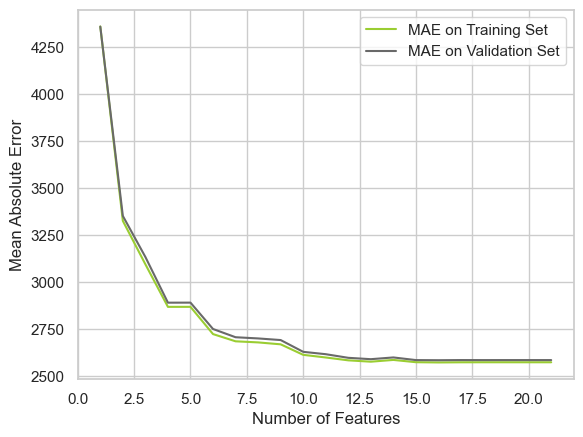

In [53]:
train_mae_list = wrapped[1]
val_mae_list = wrapped[2]

plt.plot(list(range(1,len(train_mae_list)+1)), train_mae_list, label="MAE on Training Set", color='yellowgreen')
plt.plot(list(range(1,len(val_mae_list)+1)), val_mae_list, label="MAE on Validation Set", color='dimgray')
plt.xlabel("Number of Features")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

<a class="anchor" id="5_3">

## **8.4 Embedded Methods**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_3_1">

### **8.4.1 Lasso**

[Back to TOP](#TOP)
</a>

In [54]:
embedded_cols = lasso_selection(X_train[fm_2], y_train, coef_threshold=100, return_summary=True)

[ 2.52965201e+03 -1.86540334e+03 -7.12578180e+01 -3.33139508e+03
  4.28875066e+03 -3.55561539e+00 -2.39865378e+01  4.27085791e+02
  4.99326472e+02  5.39674616e+02  3.36489407e+03 -8.51879957e+02
 -4.42389403e+01  1.48420958e+02 -1.24106090e+03  5.29423109e+01
  4.45451336e+02  1.88436086e+02  2.03987409e+03  3.59543109e+03
  8.31731254e+02]
Total features kept: 16
Features selected by Lasso method: ['year', 'mileage', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
Nº Features eliminated: 5


<a class="anchor" id="8_5">

## **8.5 Feature Importance**

[Back to TOP](#TOP)
</a>

In [55]:
mae_importance = DecisionTreeRegressor(criterion='absolute_error', random_state=42).fit(X_train[fm_2], y_train).feature_importances_
df_fi = pd.DataFrame(mae_importance, index=X_train[fm_2].columns, columns=['MAE Importance'])

<Axes: >

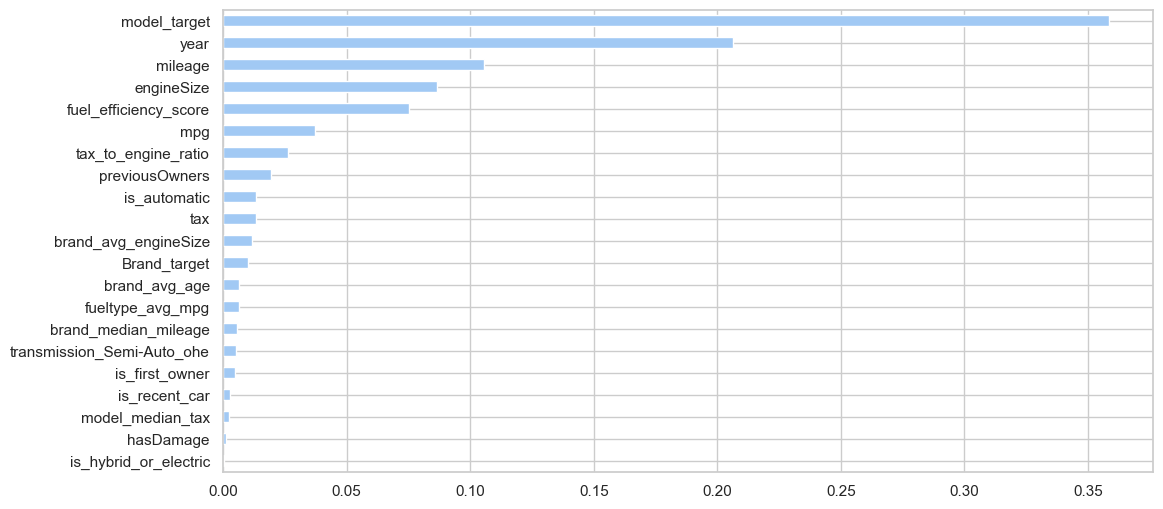

In [56]:
df_fi = pd.DataFrame(mae_importance, index=X_train[fm_2].columns, columns=['MAE Importance'])
df_fi['MAE Importance'].sort_values().plot(kind='barh', figsize=(12,6))

In [57]:
feature_importance_cols = (
    df_fi
    .sort_values('MAE Importance', ascending=False)
    .head(6)
    .index
    .tolist()
)
feature_importance_cols

['model_target',
 'year',
 'mileage',
 'engineSize',
 'fuel_efficiency_score',
 'mpg']

<a class="anchor" id="5_4">

## **8.5 Comparison between Models**

[Back to TOP](#TOP)
</a>

As described previously, the outputs of the different feature selection methods are compared in order to identify features that consistently emerge as relevant for the regression task. 

A custom function is used to perform this comparison by selecting features that are retained by at least a predefined minimum number of methods (n_agreed). For instance, when n_agreed = 2, the function returns all features that were selected by two or more of the applied feature selection methods.

Initially, the feature sets obtained for different values of n_agreed are analysed to understand how the size and composition of the selected feature set change as the agreement threshold varies. Based on this analysis, an appropriate threshold is chosen.
The resulting set of selected features is then assigned to a variable and used to construct the final modeling dataset, which includes only the predictors deemed most informative and consistently relevant across the applied methods.

In [46]:
# Check number of selected features by different agreement levels
for i in range(1, 5):
    comparison_feature_selection(X_train[fm_2], filter_cols, wrapped_cols, embedded_cols, 
                                                 feature_importance_cols, n_agreed=i, return_summary=True)[1]
    print('---' * 20)
    print('' * 2)

Total features before selection: 21
Total features selected by at least 1 methods: 17
Selected features: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
------------------------------------------------------------

Total features before selection: 21
Total features selected by at least 2 methods: 16
Selected features: ['year', 'mileage', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
------------------------------------------------------------

Total features before selection: 21
Total features selected by at least

In [47]:
selected_features = comparison_feature_selection(X_train[fm_2], filter_cols, wrapped_cols, embedded_cols, 
                                                 feature_importance_cols, n_agreed=2)[0]

# Define final datasets with selected features
X_train_final = X_train[selected_features]
X_val_final = X_val[selected_features]
test_final = test[selected_features]

At this stage, a dictionary is created to store the different feature subsets corresponding to each value of n_agreed. This structure allows all combinations of selected features to be organized and easily accessed.
The purpose of this dictionary is to enable a later systematic comparison of model performance across different feature subsets, facilitating the evaluation of how varying levels of feature agreement impact predictive accuracy.

In [48]:
# Create a list of feature selection lists for different agreement levels
fs_dict = {}
for i in range(1,5):
    fs_cols = comparison_feature_selection(X_train[fm_2], filter_cols, wrapped_cols, embedded_cols, 
                                                 feature_importance_cols, n_agreed=i)[0]
    fs_dict[f'fs_{i}_agreed'] = fs_cols

<a class="anchor" id="1">

# **9. Model and Evaluation**

[Back to TOP](#TOP)
</a>

Following the feature selection stage, this section focuses on training and evaluating multiple regression algorithms to predict the target variable. The analysis begins with the establishment of a baseline model and progressively explores more complex approaches, allowing performance improvements to be assessed in a structured and consistent manner.

The modeling workflow relies on a set of custom functions implemented in the model_and_assessment.py file. These functions apply RandomizedSearchCV for hyperparameter tuning and identify the best-performing model configuration based on the Mean Absolute Error (MAE) metric.

To ensure a controlled and reproducible evaluation strategy, the training and validation datasets are concatenated and labeled to create a PredefinedSplit. This setup guarantees that RandomizedSearchCV strictly follows the original train–validation partition during hyperparameter optimization, preventing data leakage and enabling fair comparisons across different models.

For each algorithm evaluated, the corresponding function fits the model using the training subset and generates predictions for both the training and validation datasets. This allows performance metrics to be computed consistently across models and datasets.

The primary objective of this section is to identify a model that generalizes well and is capable of accurately predicting car resale prices for unseen data, including the final test dataset for which target values are not available.
To support a robust assessment of generalization performance, the MAE gap between the training and validation sets is also computed. This metric provides insight into potential overfitting, helping to distinguish models that merely memorize training data from those that learn patterns that generalize effectively to new observations.


In [49]:
X_train = X_train_final.copy()
X_val = X_val_final.copy()
test = test_final.copy()

In [50]:
# Combine train and validation datasets
X_combined = np.concatenate([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val], axis=0)

# Create a test fold index (-1 for train, 0 for validation)
test_fold = [-1] * len(X_train) + [0] * len(X_val)

print('Test fold: ', len(test_fold))
print('X_combined: ', len(X_combined))
print('y_combined: ', len(y_combined))

# Define the PredefinedSplit
ps = PredefinedSplit(test_fold=test_fold) # aqui diz que os dados de treino são os que têm label -1 e os de validação são os que têm label 0

Test fold:  75973
X_combined:  75973
y_combined:  75973


<a class="anchor" id="5_1">

## **9.1** Create a Sample to Test Models

[Back to TOP](#TOP)
</a>

In this subsection, we create a sample of our datasets to test the modelling structure and ensure that the code is correctly implemented. Working with a smaller subset speeds up experimentation and allows us to verify the functionality of our models more efficiently. This approach also helps us identify potential issues earlier in the process.

In [51]:
X_train_s = X_train.sample(1000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]
X_val_s = X_val.sample(500, random_state=42)
y_val_s = y_val.loc[X_val_s.index]

# Recriar combined sample
sample_X_combined = np.concatenate([X_train_s, X_val_s])
sample_y_combined = np.concatenate([y_train_s, y_val_s])

# Novo fold correto!
sample_test_fold = [-1] * len(X_train_s) + [0] * len(X_val_s)

ps_sample = PredefinedSplit(sample_test_fold)

<a class="anchor" id="9_2">

## **9.2** Define the Scores to Evaluate

[Back to TOP](#TOP)
</a>

In this subsection, we define the evaluation metrics that will be used to assess model performance. We create a dictionary containing the selected scoring functions, which can later be passed directly to the RandomizedSearchCV during hyperparameter tuning.

In [46]:
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}

<a class="anchor" id="9_3">

## **9.3** Test Different Models

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_3_1">

### **9.3.1** LinearRegression

[Back to TOP](#TOP)
</a>

This Algorithm has the following Hyperparameters:
- `fit_intercept (default=True):` If set to False, no intercept will be used in calculations, data is expected to be centered.
- `copy_X (default=True):` If True, X will be copied; else, it may be overwritten.
- `tol (default=1e-06):` The precision of the solution (coef_) is determined by tol.
- `n_jobs (default=None):` This will only provide speedup in case of sufficiently large problems.
- `positive(default=False):` Forces the coefficients to be positive. Assumes that all features increase the target.

Given the nature of these hyperparameters, we conclude that there is no need to perform hyperparameter tuning.
Therefore, we proceed by training and evaluating the default Linear Regression model.

In [112]:
# Linear Regression with Randomized Search CV
model_lr = LinearRegression()

# param_grid_lr is empty because we are not tuning any hyperparameters for Linear Regression
param_grid_lr = {
}

# Apply Randomized Search CV
rsCV_lr = apply_randomized_search_cv(
    model_lr, 
    param_grid_lr,
    iterations=1, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_lr = evaluate_model(rsCV_lr)
print("\033[1mBest Hyperparameters for Linear Regression:\033[0m", best_params_lr)
df

Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END  mae: (train=-2569.688, test=-2571.808) r2: (train=0.822, test=0.820) total time=   0.3s
Best Hyperparameters for Linear Regression: {}


,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.822,0.82,2569.688,2571.808,0.285,0.082,⬅ BEST MODEL


<a class="anchor" id="9_3_2">

### **9.3.2** Ridge

[Back to TOP](#TOP)
</a>

In [71]:
#Ridge Regression with Randomized Search CV
model_ridge = Ridge(random_state=42)

# Define parameter grid for Ridge Regression
param_grid_ridge = {
    "alpha": [0.01, 0.1, 1, 10, 100], 
    "solver": ['auto', 'svd', 'cholesky', 'sparse_cg', 'sag', 'saga']
}   

# Execute Randomized Search CV for Ridge Regression
rsCV_ridge = apply_randomized_search_cv(
    model_ridge, 
    param_grid_ridge, 
    iterations=12,
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)       

# Check results
df, best_params_ridge = evaluate_model(rsCV_ridge)
print("\033[1mBest Hyperparameters for Ridge Regression:\033[0m", best_params_ridge)
df

Fitting 1 folds for each of 12 candidates, totalling 12 fits
[CV 1/1] END alpha=0.01, solver=auto; mae: (train=-2569.688, test=-2571.807) r2: (train=0.822, test=0.820) total time=   0.0s
[CV 1/1] END alpha=100, solver=auto; mae: (train=-2569.093, test=-2571.395) r2: (train=0.822, test=0.820) total time=   0.0s
[CV 1/1] END alpha=0.1, solver=sag; mae: (train=-2569.698, test=-2571.816) r2: (train=0.822, test=0.820) total time=   0.3s
[CV 1/1] END alpha=0.1, solver=saga; mae: (train=-2569.668, test=-2571.789) r2: (train=0.822, test=0.820) total time=   0.2s
[CV 1/1] END alpha=1, solver=cholesky; mae: (train=-2569.680, test=-2571.801) r2: (train=0.822, test=0.820) total time=   0.0s
[CV 1/1] END alpha=0.1, solver=svd; mae: (train=-2569.687, test=-2571.807) r2: (train=0.822, test=0.820) total time=   0.1s
[CV 1/1] END alpha=10, solver=cholesky; mae: (train=-2569.610, test=-2571.750) r2: (train=0.822, test=0.820) total time=   0.0s
[CV 1/1] END alpha=1, solver=svd; mae: (train=-2569.680, tes

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.822,0.82,2569.688,2571.807,0.285,0.082,
1,0.822,0.82,2569.093,2571.395,0.299,0.090,⬅ BEST MODEL
2,0.822,0.82,2569.698,2571.816,0.285,0.082,
3,0.822,0.82,2569.668,2571.789,0.285,0.083,
4,0.822,0.82,2569.680,2571.801,0.285,0.083,
5,0.822,0.82,2569.687,2571.807,0.285,0.082,
6,0.822,0.82,2569.610,2571.750,0.287,0.083,
7,0.822,0.82,2569.680,2571.801,0.285,0.083,
8,0.822,0.82,2569.687,2571.807,0.285,0.082,
9,0.822,0.82,2569.699,2571.817,0.285,0.082,


<a class="anchor" id="9_3_3">

### **9.3.3** Lasso

[Back to TOP](#TOP)
</a>

In [72]:
# Lasso Regression with Randomized Search CV
model_lasso = Lasso(random_state=42)

# Define parameter grid for Lasso Regression
param_grid_lasso = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "max_iter": [1000, 5000, 10000],
    "selection": ['cyclic', 'random']
}
# Apply Randomized Search CV for Lasso Regression
rsCV_lasso = apply_randomized_search_cv(
    model_lasso, 
    param_grid_lasso, 
    iterations=30, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_lasso = evaluate_model(rsCV_lasso)
print("\033[1mBest Hyperparameters for Lasso Regression:\033[0m", best_params_lasso)
df

Fitting 1 folds for each of 30 candidates, totalling 30 fits
[CV 1/1] END alpha=0.01, max_iter=1000, selection=cyclic; mae: (train=-2569.686, test=-2571.806) r2: (train=0.822, test=0.820) total time=   0.4s
[CV 1/1] END alpha=0.01, max_iter=1000, selection=random; mae: (train=-2569.686, test=-2571.806) r2: (train=0.822, test=0.820) total time=   0.4s
[CV 1/1] END alpha=0.01, max_iter=5000, selection=cyclic; mae: (train=-2569.686, test=-2571.806) r2: (train=0.822, test=0.820) total time=   0.2s
[CV 1/1] END alpha=0.01, max_iter=5000, selection=random; mae: (train=-2569.686, test=-2571.806) r2: (train=0.822, test=0.820) total time=   0.5s
[CV 1/1] END alpha=0.01, max_iter=10000, selection=cyclic; mae: (train=-2569.686, test=-2571.806) r2: (train=0.822, test=0.820) total time=   0.2s
[CV 1/1] END alpha=0.01, max_iter=10000, selection=random; mae: (train=-2569.686, test=-2571.806) r2: (train=0.822, test=0.820) total time=   0.6s
[CV 1/1] END alpha=0.1, max_iter=1000, selection=cyclic; mae:

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.822,0.82,2569.686,2571.806,0.285,0.083,
1,0.822,0.82,2569.686,2571.806,0.285,0.083,
2,0.822,0.82,2569.686,2571.806,0.285,0.083,
3,0.822,0.82,2569.686,2571.806,0.285,0.083,
4,0.822,0.82,2569.686,2571.806,0.285,0.083,
5,0.822,0.82,2569.686,2571.806,0.285,0.083,
6,0.822,0.82,2569.663,2571.791,0.285,0.083,
7,0.822,0.82,2569.664,2571.791,0.285,0.083,
8,0.822,0.82,2569.663,2571.791,0.285,0.083,
9,0.822,0.82,2569.664,2571.791,0.285,0.083,


<a class="anchor" id="9_3_4">

### **9.3.4.** Elastic Net

[Back to TOP](#TOP)
</a>

In [74]:
# ElasticNet Regression with Randomized Search CV
model_eln = ElasticNet(random_state=42)

# Define parameter grid for ElasticNet Regression
param_grid_eln = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "max_iter": [1000, 5000, 10000],
    "selection": ['cyclic', 'random']
}   

# Apply Randomized Search CV for ElasticNet Regression
rsCV_eln = apply_randomized_search_cv(
    model_eln, 
    param_grid_eln, 
    iterations=150, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_eln = evaluate_model(rsCV_eln)
print("\033[1mBest Hyperparameters for ElasticNet:\033[0m", best_params_eln)
df

Fitting 1 folds for each of 150 candidates, totalling 150 fits
[CV 1/1] END alpha=0.01, l1_ratio=0.1, max_iter=1000, selection=cyclic; mae: (train=-2570.237, test=-2572.939) r2: (train=0.822, test=0.819) total time=   0.4s
[CV 1/1] END alpha=0.01, l1_ratio=0.1, max_iter=1000, selection=random; mae: (train=-2570.237, test=-2572.939) r2: (train=0.822, test=0.819) total time=   0.7s
[CV 1/1] END alpha=0.01, l1_ratio=0.1, max_iter=5000, selection=cyclic; mae: (train=-2570.237, test=-2572.939) r2: (train=0.822, test=0.819) total time=   0.2s
[CV 1/1] END alpha=0.01, l1_ratio=0.1, max_iter=5000, selection=random; mae: (train=-2570.237, test=-2572.939) r2: (train=0.822, test=0.819) total time=   0.5s
[CV 1/1] END alpha=0.01, l1_ratio=0.1, max_iter=10000, selection=cyclic; mae: (train=-2570.237, test=-2572.939) r2: (train=0.822, test=0.819) total time=   0.2s
[CV 1/1] END alpha=0.01, l1_ratio=0.1, max_iter=10000, selection=random; mae: (train=-2570.237, test=-2572.939) r2: (train=0.822, test=0

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.822,0.819,2570.237,2572.939,0.352,0.105,
1,0.822,0.819,2570.237,2572.939,0.352,0.105,
2,0.822,0.819,2570.237,2572.939,0.352,0.105,
3,0.822,0.819,2570.237,2572.939,0.352,0.105,
4,0.822,0.819,2570.237,2572.939,0.352,0.105,
...,...,...,...,...,...,...,...
146,0.357,0.352,5363.720,5339.151,1.473,0.458,
147,0.357,0.352,5363.701,5339.131,1.473,0.458,
148,0.357,0.352,5363.720,5339.151,1.473,0.458,
149,0.357,0.352,5363.701,5339.131,1.473,0.458,


<a class="anchor" id="9_3_1">

### **9.3.1.** KNN

[Back to TOP](#TOP)
</a>

In [113]:
# KNN Regression with Randomized Search CV
model_KNN = KNeighborsRegressor()

# Define parameter grid for KNN Regression
param_grid_knn = {
    "n_neighbors": [5, 10, 15, 20],
    "algorithm": ["kd_tree", "auto"], # we are excluding 'brute' and 'ball_tree' due to previous similar performance
    "leaf_size": [12, 30], 
    "p": [1], # we are focusing on Manhattan distance cause it performed better in previous tests
    "metric": ["manhattan", "euclidean", "minkowski"]
}

# Apply Randomized Search CV for KNN Regression
rsCV_knn = apply_randomized_search_cv(
    model_KNN, 
    param_grid_knn, 
    iterations=48, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_knn = evaluate_model(rsCV_knn)
print("\033[1mBest Hyperparameters for KNN Regression:\033[0m", best_params_knn)
df

Fitting 1 folds for each of 48 candidates, totalling 48 fits
[CV 1/1] END algorithm=kd_tree, leaf_size=12, metric=manhattan, n_neighbors=5, p=1; mae: (train=-1142.552, test=-1416.692) r2: (train=0.954, test=0.937) total time=   1.8s
[CV 1/1] END algorithm=kd_tree, leaf_size=12, metric=manhattan, n_neighbors=10, p=1; mae: (train=-1302.101, test=-1451.402) r2: (train=0.940, test=0.933) total time=   1.7s
[CV 1/1] END algorithm=kd_tree, leaf_size=12, metric=manhattan, n_neighbors=15, p=1; mae: (train=-1386.837, test=-1495.831) r2: (train=0.933, test=0.927) total time=   2.3s
[CV 1/1] END algorithm=kd_tree, leaf_size=12, metric=manhattan, n_neighbors=20, p=1; mae: (train=-1449.607, test=-1542.048) r2: (train=0.926, test=0.921) total time=   2.7s
[CV 1/1] END algorithm=kd_tree, leaf_size=12, metric=euclidean, n_neighbors=5, p=1; mae: (train=-1197.269, test=-1484.789) r2: (train=0.951, test=0.933) total time=   1.3s
[CV 1/1] END algorithm=kd_tree, leaf_size=12, metric=euclidean, n_neighbors=

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.954,0.937,1142.552,1416.692,1.774,23.994,
1,0.940,0.933,1302.101,1451.402,0.811,11.466,
2,0.933,0.927,1386.837,1495.831,0.595,7.859,
3,0.926,0.921,1449.607,1542.048,0.572,6.377,
4,0.951,0.933,1197.269,1484.789,1.916,24.015,
5,0.934,0.926,1369.314,1524.062,0.836,11.301,
6,0.926,0.918,1458.626,1572.619,0.816,7.815,
7,0.920,0.914,1522.204,1613.569,0.716,6.002,
8,0.954,0.937,1142.552,1416.692,1.774,23.994,
9,0.940,0.933,1302.101,1451.402,0.811,11.466,


<a class="anchor" id="9_3_1">

### **9.3.1** Neural Networks

[Back to TOP](#TOP)
</a>

In [ ]:
model_MLP = MLPRegressor(random_state=42)

param_grid_mlp = {
    "hidden_layer_sizes": [(50, 50, 50), (250, 150, 100), (200, 150)],
    "activation": ["relu"], 
    "solver": ["adam"], 
    "alpha": [0.00003], 
    "batch_size": [64],
    'learning_rate': ['constant'],
    'learning_rate_init': [0.003],
    'power_t': [0.5, 0.2, 0.8],
    "max_iter": [500],
    'tol': [0.0001, 0.001],
    'early_stopping': [True],
    'n_iter_no_change': [30, 50]
}

rsCV_mlp = apply_randomized_search_cv(
    model_MLP, 
    param_grid_mlp, 
    iterations=36, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)   

# Check results
df, best_params_mlp = evaluate_model(rsCV_mlp)
print("\033[1mBest Hyperparameters for MLP Regressor:\033[0m", best_params_mlp)
df

Fitting 1 folds for each of 36 candidates, totalling 36 fits
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=30, power_t=0.5, solver=adam, tol=0.0001; mae: (train=-1491.446, test=-1580.999) r2: (train=0.942, test=0.931) total time= 3.5min
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=30, power_t=0.5, solver=adam, tol=0.001; mae: (train=-1682.663, test=-1720.378) r2: (train=0.918, test=0.915) total time= 1.1min
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=30, power_t=0.2, solver=adam, tol=0.0001; mae: (train=-1491.446, test=-1580.999) r2: (train=0.942, te

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=50, power_t=0.5, solver=adam, tol=0.0001; mae: (train=-1457.498, test=-1548.349) r2: (train=0.943, test=0.932) total time= 3.9min
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=50, power_t=0.5, solver=adam, tol=0.001; mae: (train=-1648.790, test=-1685.812) r2: (train=0.922, test=0.920) total time= 1.6min


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=50, power_t=0.2, solver=adam, tol=0.0001; mae: (train=-1457.498, test=-1548.349) r2: (train=0.943, test=0.932) total time= 3.9min
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=50, power_t=0.2, solver=adam, tol=0.001; mae: (train=-1648.790, test=-1685.812) r2: (train=0.922, test=0.920) total time= 1.6min


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=50, power_t=0.8, solver=adam, tol=0.0001; mae: (train=-1457.498, test=-1548.349) r2: (train=0.943, test=0.932) total time= 3.9min
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(50, 50, 50), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=50, power_t=0.8, solver=adam, tol=0.001; mae: (train=-1648.790, test=-1685.812) r2: (train=0.922, test=0.920) total time= 1.6min
[CV 1/1] END activation=relu, alpha=3e-05, batch_size=64, early_stopping=True, hidden_layer_sizes=(250, 150, 100), learning_rate=constant, learning_rate_init=0.003, max_iter=500, n_iter_no_change=30, power_t=0.5, solver=adam, tol=0.0001; mae: (train=-1415.467, test=-1524.162) r2: (train=0.947, test=0.937) total time= 5.6min
[CV 1/1] END activation=relu,

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.942,0.931,1491.446,1580.999,1.153,6.004,
1,0.918,0.915,1682.663,1720.378,0.269,2.241,
2,0.942,0.931,1491.446,1580.999,1.153,6.004,
3,0.918,0.915,1682.663,1720.378,0.269,2.241,
4,0.942,0.931,1491.446,1580.999,1.153,6.004,
5,0.918,0.915,1682.663,1720.378,0.269,2.241,
6,0.943,0.932,1457.498,1548.349,1.130,6.233,
7,0.922,0.920,1648.790,1685.812,0.219,2.245,
8,0.943,0.932,1457.498,1548.349,1.130,6.233,
9,0.922,0.920,1648.790,1685.812,0.219,2.245,


<a class="anchor" id="9_4">

## **9.4** Decision Trees 

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_5">

## **9.5.** Ensemble Methods

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_5_1">

### **9.5.1.** With Decision Trees

[Back to TOP](#TOP)
</a>

In [80]:
# The parameters here used were obtained from the RandomizedSearchCV above done with RandomForestRegressor
estimator_dt = DecisionTreeRegressor(max_depth=18, min_samples_split=10, min_samples_leaf=5, max_features=None, random_state=42)
model_bag_dt = BaggingRegressor(estimator = estimator_dt, random_state = 42)

# Define parameter grid for Bagging Regressor with Decision Tree base estimator
param_grid_bag_dt = {
    "n_estimators": [50, 80, 120, 150],       # Number of decision trees
    "max_samples": [0.5, 0.7, 0.8, 0.9],      # Fraction of the dataset to sample
    "max_features": [0.4, 0.5, 0.6, 0.8],     # Fraction of features to sample (if max_features = 1 then all features are used and the results obtain were terrible)
    "bootstrap": [True],          # Sampling with or without replacement
    "bootstrap_features": [False]  # Feature sampling with or without replacement
}

# Apply Randomized Search CV
rsCV_bag_dt = apply_randomized_search_cv(
    model_bag_dt, 
    param_grid_bag_dt, 
    iterations= 64, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_bag_dt = evaluate_model(rsCV_bag_dt)
print("\033[1mBest Hyperparameters for Bagging Regressor with Decision Tree:\033[0m", best_params_bag_dt)
df


Fitting 1 folds for each of 64 candidates, totalling 64 fits
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=50; mae: (train=-1583.188, test=-1729.577) r2: (train=0.923, test=0.908) total time=   2.3s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=80; mae: (train=-1515.811, test=-1671.944) r2: (train=0.929, test=0.913) total time=   3.6s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=120; mae: (train=-1502.829, test=-1658.929) r2: (train=0.930, test=0.914) total time=   5.7s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=150; mae: (train=-1527.735, test=-1678.788) r2: (train=0.928, test=0.913) total time=   7.0s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.7, n_estimators=50; mae: (train=-1534.827, test=-1706.025) r2: (train=

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.923,0.908,1583.188,1729.577,1.684,9.247,
1,0.929,0.913,1515.811,1671.944,1.686,10.300,
2,0.930,0.914,1502.829,1658.929,1.652,10.387,
3,0.928,0.913,1527.735,1678.788,1.639,9.887,
4,0.929,0.912,1534.827,1706.025,1.867,11.154,
...,...,...,...,...,...,...,...
60,0.959,0.942,1083.930,1335.509,1.865,23.210,
61,0.960,0.942,1080.359,1329.525,1.832,23.063,⬅ BEST MODEL
62,0.960,0.942,1078.395,1335.623,1.876,23.853,
63,0.960,0.942,1079.777,1335.811,1.890,23.712,


<a class="anchor" id="9_5_2">

### **9.5.2.** Random Forest

[Back to TOP](#TOP)
</a>

In [45]:
# Random Forest Regressor with Randomized Search CV
model_rf_1 = RandomForestRegressor(random_state=42)

# Define parameter grid for Random Forest Regressor (Set 1)
param_grid_rf_1 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 8, 10, 12, 15],
    'min_samples_split': [2, 5, 8, 10, 12, 15],
    'min_samples_leaf': [1, 5, 8, 10],
    'max_features': [1, 'sqrt', 'log2', 0.5],
    'ccp_alpha': [0.0, 0.01, 0.1, 0.2],
}

# Apply Randomized Search CV
rsCV_rf_1 = apply_randomized_search_cv(
    model_rf_1, 
    param_grid_rf_1, 
    iterations=100, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_rf_1 = evaluate_model(rsCV_rf_1)
print("\033[1mBest Hyperparameters for Random Forest Regressor (Set 1):\033[0m", best_params_rf_1)
df

NameError: name 'scoring' is not defined

In [116]:
# Random Forest Regressor with Randomized Search CV
model_rf_2 = RandomForestRegressor(random_state=42)

# Define parameter grid for Random Forest Regressor (Set 2)
param_grid_rf_2 = {
    'n_estimators': [100],
    'max_depth': [None, 8, 12, 15],
    'min_samples_split': [5, 8, 12],
    'min_samples_leaf': [5, 8, 10],
    'max_features': [1, 'sqrt', 'log2', 0.5],
    'ccp_alpha': [0.0, 0.2],
}

# Apply Randomized Search CV
rsCV_rf_2 = apply_randomized_search_cv(
    model_rf_2, 
    param_grid_rf_2, 
    iterations=50, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_rf_2 = evaluate_model(rsCV_rf_2)
print("\033[1mBest Hyperparameters for Random Forest Regressor (Set 2):\033[0m", best_params_rf_2)
df

Fitting 1 folds for each of 50 candidates, totalling 50 fits
[CV 1/1] END ccp_alpha=0.0, max_depth=12, max_features=sqrt, min_samples_leaf=5, min_samples_split=8, n_estimators=100; mae: (train=-1379.035, test=-1492.481) r2: (train=0.943, test=0.932) total time=   4.2s
[CV 1/1] END ccp_alpha=0.0, max_depth=12, max_features=log2, min_samples_leaf=5, min_samples_split=5, n_estimators=100; mae: (train=-1379.035, test=-1492.481) r2: (train=0.943, test=0.932) total time=   4.3s
[CV 1/1] END ccp_alpha=0.0, max_depth=15, max_features=0.5, min_samples_leaf=5, min_samples_split=5, n_estimators=100; mae: (train=-1139.675, test=-1354.466) r2: (train=0.957, test=0.941) total time=   8.8s
[CV 1/1] END ccp_alpha=0.0, max_depth=None, max_features=0.5, min_samples_leaf=10, min_samples_split=8, n_estimators=100; mae: (train=-1230.292, test=-1400.808) r2: (train=0.946, test=0.932) total time=   8.7s
[CV 1/1] END ccp_alpha=0.0, max_depth=8, max_features=sqrt, min_samples_leaf=10, min_samples_split=5, n_es

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.943,0.932,1379.035,1492.481,1.180,8.226,
1,0.943,0.932,1379.035,1492.481,1.180,8.226,
2,0.957,0.941,1139.675,1354.466,1.744,18.847,
3,0.946,0.932,1230.292,1400.808,1.494,13.860,
4,0.909,0.904,1806.213,1838.077,0.648,1.764,
5,0.911,0.905,1805.569,1835.253,0.599,1.644,
6,0.938,0.927,1345.191,1466.612,1.235,9.026,
7,0.953,0.937,1173.951,1375.804,1.686,17.194,
8,0.913,0.908,1800.736,1829.621,0.511,1.604,
9,0.942,0.930,1308.014,1446.726,1.308,10.605,


<a class="anchor" id="9_5_3">

### **9.5.3.** ExtraTrees

[Back to TOP](#TOP)
</a>

In [92]:
# Extra Trees Regressor with Randomized Search CV
model_et = ExtraTreesRegressor(random_state=42)

# Define parameter grid for Extra Trees Regressor
param_grid_et = {
    'n_estimators': [100, 200],
    'criterion': ['squared_error'],
    'max_depth': [None, 12, 25, 30],
    'min_samples_split': [8, 12, 15],
    'min_samples_leaf': [1, 3],
    'max_features': [0.5, None, 'sqrt'],
    'bootstrap': [True],
    'max_samples': [0.6, 0.7, 0.8]
}


# Apply Randomized Search CV
rsCV_et = apply_randomized_search_cv(
    model_et, 
    param_grid_et, 
    iterations=100, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_et = evaluate_model(rsCV_et)
print("\033[1mBest Hyperparameters for Extra Trees Regressor:\033[0m", best_params_et)
df

Fitting 1 folds for each of 100 candidates, totalling 100 fits
[CV 1/1] END bootstrap=True, criterion=squared_error, max_depth=25, max_features=0.5, max_samples=0.6, min_samples_leaf=1, min_samples_split=15, n_estimators=100; mae: (train=-1242.090, test=-1410.657) r2: (train=0.949, test=0.934) total time=   2.4s
[CV 1/1] END bootstrap=True, criterion=squared_error, max_depth=None, max_features=None, max_samples=0.7, min_samples_leaf=3, min_samples_split=12, n_estimators=100; mae: (train=-1202.047, test=-1376.842) r2: (train=0.950, test=0.939) total time=   4.0s
[CV 1/1] END bootstrap=True, criterion=squared_error, max_depth=None, max_features=None, max_samples=0.8, min_samples_leaf=1, min_samples_split=12, n_estimators=200; mae: (train=-1066.459, test=-1330.077) r2: (train=0.963, test=0.943) total time=   9.7s
[CV 1/1] END bootstrap=True, criterion=squared_error, max_depth=30, max_features=sqrt, max_samples=0.7, min_samples_leaf=1, min_samples_split=12, n_estimators=100; mae: (train=-1

,Train_R2,Val_R2,Train_MAE,Val_MAE,Gap_R2_%,Gap_MAE_%,Best_Model
0,0.949,0.934,1242.090,1410.657,1.519,13.571,
1,0.950,0.939,1202.047,1376.842,1.212,14.541,
2,0.963,0.943,1066.459,1330.077,2.030,24.719,
3,0.949,0.933,1234.323,1420.951,1.644,15.120,
4,0.945,0.934,1283.229,1427.612,1.105,11.252,
...,...,...,...,...,...,...,...
95,0.947,0.932,1260.275,1435.743,1.577,13.923,
96,0.964,0.944,1052.291,1324.590,2.042,25.877,
97,0.938,0.930,1460.419,1547.499,0.797,5.963,
98,0.957,0.941,1129.819,1351.725,1.729,19.641,


<a class="anchor" id="9_5_4">

### **9.5.4.** With MLP

[Back to TOP](#TOP)
</a>

In [ ]:
# Bagging Regressor with MLP base estimator and Randomized Search CV
estimator_mlp = MLPRegressor(hidden_layer_sizes=(32, 16), activation='relu', solver='adam', learning_rate_init=0.003, learning_rate='constant', alpha=0.00003, max_iter=700, batch_size=64, early_stopping=True, tol = 0.0001, n_iter_no_change = 30, random_state=42)
model_bag_mlp = BaggingRegressor(estimator = estimator_mlp, random_state = 42)

# Define parameter grid for Bagging Regressor with MLP base estimator
param_grid_bag_mlp = {
    "n_estimators": [50, 80, 120, 150],       # Number of decision trees
    "max_samples": [0.5, 0.7, 0.8, 0.9],      # Fraction of the dataset to sample
    "max_features": [0.4, 0.5, 0.6, 0.8],     # Fraction of features to sample (if max_features = 1 then all features are used and the results obtain were terrible)
    "bootstrap": [True],          # Sampling with or without replacement
    "bootstrap_features": [False]  # Feature sampling with or without replacement
}

# Apply Randomized Search CV
rsCV_bag_mlp = apply_randomized_search_cv(
    model_bag_mlp, 
    param_grid_bag_mlp, 
    iterations= 1, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
df, best_params_bag_mlp = evaluate_model(rsCV_bag_mlp)
print("\033[1mBest Hyperparameters for Bagging Regressor with MLP base estimator:\033[0m", best_params_bag_mlp)
df

Fitting 1 folds for each of 1 candidates, totalling 1 fits


/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


# Get results

In [103]:
models = [
    ("Linear Regression", rsCV_lr),
    ("Ridge Regression", rsCV_ridge),
    ("Lasso Regression", rsCV_lasso),
    ("ElasticNet Regression", rsCV_eln),
    #("KNN Regression", rsCV_knn),
    #("MLP Regressor", rsCV_mlp),
    #("Decision Tree Regressor", rsCV_bag_dt),
    ("Bagging Regressor (Decision Tree)", rsCV_bag_dt),
    ("Random Forest Regressor 1", rsCV_rf_1),
    ("Random Forest Regressor 2", rsCV_rf_2),
    ("Extra Trees Regressor", rsCV_et),
    #("Bagging Regressor (MLP)", rsCV_bag_mlp)
]

comparison_df = final_models_comparison(models)
comparison_df

,Algorithm,Train MAE,Val MAE,Gap MAE (%),Train R2,Val R2,Gap R2 (%),Fit Time (s)
0,Linear Regression,2569.688,2571.808,0.082,0.822,0.820,0.285,0.160
1,Ridge Regression,2569.093,2571.395,0.090,0.822,0.820,0.299,0.015
2,Lasso Regression,2569.455,2571.662,0.086,0.822,0.820,0.288,0.117
3,ElasticNet Regression,2568.893,2571.317,0.094,0.822,0.820,0.309,0.238
4,Bagging Regressor (Decision Tree),1080.359,1329.525,23.063,0.960,0.942,1.832,9.898
5,Random Forest Regressor 1,1005.737,1322.907,31.536,0.975,0.948,2.774,16.222
6,Random Forest Regressor 2,1054.187,1326.911,25.871,0.961,0.942,1.943,19.147
7,Extra Trees Regressor,966.363,1300.114,34.537,0.970,0.947,2.375,10.017


In [ ]:
# EXEMPLO DO QUE PRECISAMOS DE FAZER QUANDO ESCOLHERMOS O MELHOR MODELO

#best_model = rsCV_et.best_estimator_
#save_Kaggle(best_model, test, model_name="extra_trees_regressor")

# Open ended

## Feature Selection Influence

### Linear Regression

In [47]:
# Apply comparison function that compares model performance across different feature sets
compare_feature_sets(fs_dict, LinearRegression(), X_train_no_fs, y_train, X_val_no_fs, y_val)

,Num_Features,Train_MAE,Val_MAE,Gap_MAE_%,Train_R2,Val_R2
fs_2_agreed,16,2569.688080,2571.807546,0.082480,0.822267,0.819923
fs_1_agreed,17,2570.449799,2572.715263,0.088135,0.822270,0.819912
fs_3_agreed,14,2572.560627,2576.224940,0.142438,0.821475,0.818899
fs_4_agreed,6,2724.330001,2727.798798,0.127327,0.804381,0.801918


### Ridge

In [48]:
# Define best model Ridge Regression from previous Randomized Search CV
model_ridge = Ridge(solver = 'auto', alpha = 100, random_state=42)
compare_feature_sets(fs_dict, model_ridge, X_train_no_fs, y_train, X_val_no_fs, y_val)

,Num_Features,Train_MAE,Val_MAE,Gap_MAE_%,Train_R2,Val_R2
fs_2_agreed,16,2569.093008,2571.394707,0.089592,0.822249,0.819794
fs_1_agreed,17,2570.484842,2573.038946,0.099363,0.822251,0.819774
fs_3_agreed,14,2571.564209,2575.532829,0.154327,0.821458,0.818771
fs_4_agreed,6,2723.775458,2727.239872,0.127192,0.804374,0.801855


### Lasso

In [49]:
model_lasso = Lasso(max_iter = 1000, alpha = 1, random_state=42)
compare_feature_sets(fs_dict, model_lasso, X_train_no_fs, y_train, X_val_no_fs, y_val)

,Num_Features,Train_MAE,Val_MAE,Gap_MAE_%,Train_R2,Val_R2
fs_2_agreed,16,2569.454919,2571.661934,0.085894,0.822265,0.819896
fs_1_agreed,17,2570.339682,2572.709833,0.092212,0.822268,0.819884
fs_3_agreed,14,2572.267112,2576.030420,0.146303,0.821474,0.818877
fs_4_agreed,6,2724.163729,2727.638164,0.127541,0.804381,0.801906


### Elastic Net

In [110]:
# Define best model Elastic Net Regression from previous Randomized Search CV
model_eln = ElasticNet(alpha = 0.01, l1_ratio = 0.7, max_iter = 1000, selection = 'cyclic', random_state=42)
compare_feature_sets(fs_dict, model_eln, X_train_no_fs, y_train, X_val_no_fs, y_val)

,Num_Features,Train_MAE,Val_MAE,Gap_MAE_%,Train_R2,Val_R2
fs_2_agreed,16,2568.892828,2571.317057,0.094369,0.822211,0.819668
fs_1_agreed,17,2570.742717,2573.524247,0.108199,0.822211,0.819642
fs_3_agreed,14,2571.039813,2575.242751,0.163472,0.821419,0.818646
fs_4_agreed,6,2723.428218,2726.882719,0.126844,0.804357,0.801793


### KNN

In [111]:
# Define best model Elastic Net Regression from previous Randomized Search CV
model_knn = KNeighborsRegressor(n_neighbors=10, algorithm='kd_tree', leaf_size=12, p=1, metric='manhattan')
compare_feature_sets(fs_dict, model_knn, X_train_no_fs, y_train, X_val_no_fs, y_val)

,Num_Features,Train_MAE,Val_MAE,Gap_MAE_%,Train_R2,Val_R2
fs_3_agreed,14,1296.366988,1445.157914,11.477531,0.941136,0.933525
fs_2_agreed,16,1302.101499,1451.401665,11.466093,0.940419,0.932793
fs_1_agreed,17,1309.830215,1462.527601,11.657800,0.940108,0.932020
fs_4_agreed,6,1368.380073,1519.261639,11.026291,0.936761,0.929241


### MLP

In [ ]:
# # Define best model Elastic Net Regression from previous Randomized Search CV
# model_mlp = MLPRegressor(hidden_layer_sizes = (250, 150, 100), alpha = 3e-05, batch_size = 64, 
#                          learning_rate = 'constant', learning_rate_init = 0.003, max_iter = 500,
#                          random_state = 42, early_stopping = True)
# compare_feature_sets(fs_dict, model_mlp, X_train_no_fs, y_train, X_val_no_fs, y_val)

### Decision Trees

### Bagging with Decision Trees

### Random Forest

### Extra Trees

### Bagging with MLP